# Preprocess Method

Demonstração passo a passo do pipeline de pré-processamento aplicado ao primeiro frame do vídeo **tiger1**:

1. Carregamento do primeiro frame
2. Remoção de fundo (`AdaptiveBackgroundModel` do tracker)
3. Binarização (Otsu)
4. Geração das regiões de busca

In [39]:
import sys
sys.path.append('/mnt/c/Users/Isabella/tcc')

import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from wisard_object_tracker.src.utils import tracker_utils

DATASET_ROOT = '/mnt/c/Users/Isabella/TCC/wisard_object_tracker/data/david'
IMAGE_FOLDER = os.path.join(DATASET_ROOT, 'imgs')
GT_PATH      = os.path.join(DATASET_ROOT, 'david_gt.txt')

OUTPUT_DIR = Path('preprocess_method_output')
OUTPUT_DIR.mkdir(exist_ok=True)

image_paths   = sorted(glob.glob(os.path.join(IMAGE_FOLDER, '*.png')))
ground_truths = tracker_utils.load_ground_truth_from_gt_txt(GT_PATH)

print(f'Imagens encontradas : {len(image_paths)}')
print(f'Ground truths       : {len(ground_truths)}')

Imagens encontradas : 462
Ground truths       : 462


## 1. Carregamento do primeiro frame

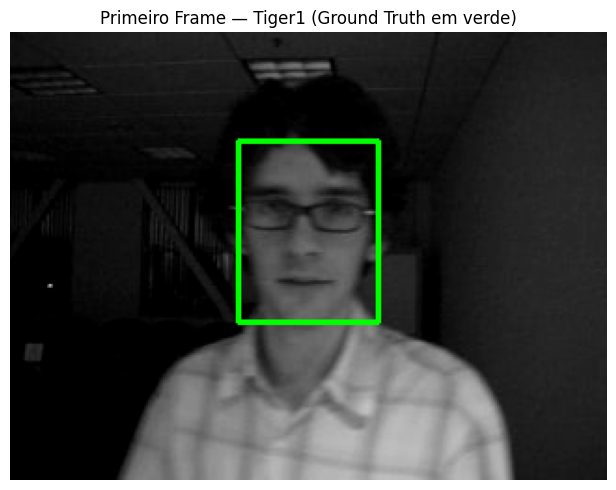

Shape : (240, 320, 3)
GT    : (122.0, 58.0, 75.0, 97.0)


In [40]:
first_frame = cv2.cvtColor(cv2.imread(image_paths[0]), cv2.COLOR_BGR2RGB)
first_gt    = ground_truths[0]
x, y, w, h  = map(int, first_gt)

frame_with_gt = first_frame.copy()
cv2.rectangle(frame_with_gt, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.figure(figsize=(8, 5))
plt.imshow(frame_with_gt)
plt.title('Primeiro Frame — Tiger1 (Ground Truth em verde)')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Shape : {first_frame.shape}')
print(f'GT    : {first_gt}')

## 2. Remoção de fundo — `AdaptiveBackgroundModel`

Classe extraída de `T-wisard.py`. O background é inicializado com o primeiro frame, com a região do objeto zerada. Em seguida `apply()` computa a diferença absoluta, aplica limiarização e retorna apenas o foreground.

In [41]:
class AdaptiveBackgroundModel:

    def __init__(self, alpha=0.01, threshold=25):
        self.alpha     = alpha
        self.threshold = threshold
        self.background = None

    def initialize(self, frame, bbox=None):
        bg = frame.astype(np.float32)
        if bbox is not None:
            bx, by, bw, bh = map(int, bbox)
            bg[by:by+bh, bx:bx+bw] = 0
        self.background = bg

    def apply(self, frame):
        frame_f    = frame.astype(np.float32)
        background = self.background.astype(np.float32)

        diff = cv2.absdiff(frame_f, background)
        gray = cv2.cvtColor(diff.astype(np.uint8), cv2.COLOR_RGB2GRAY)

        _, mask = cv2.threshold(gray, self.threshold, 255, cv2.THRESH_BINARY)
        mask = cv2.medianBlur(mask, 5)

        fg = cv2.bitwise_and(frame, frame, mask=mask)

        inv_mask    = cv2.bitwise_not(mask)
        inv_mask_3c = np.repeat(inv_mask[:, :, None] / 255.0, 3, axis=2)

        self.background = (
            inv_mask_3c * ((1 - self.alpha) * background + self.alpha * frame_f)
            + (1 - inv_mask_3c) * background
        ).astype(np.float32)

        return fg

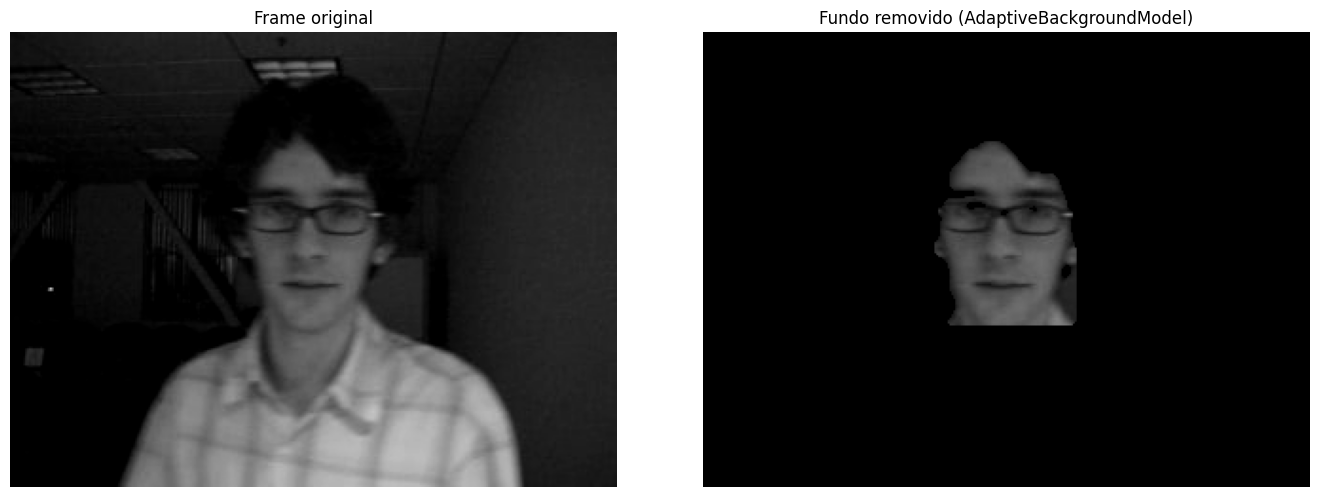

Resultado intermediário salvo em: preprocess_method_output/frame_sem_fundo.png


In [42]:
BACKGROUND_ALPHA = 0.1

bg_model = AdaptiveBackgroundModel(alpha=BACKGROUND_ALPHA)
bg_model.initialize(first_frame, first_gt)
frame_no_bg = bg_model.apply(first_frame)

# Salva resultado intermediário
no_bg_path = OUTPUT_DIR / 'frame_sem_fundo.png'
cv2.imwrite(str(no_bg_path), cv2.cvtColor(frame_no_bg, cv2.COLOR_RGB2BGR))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(first_frame)
axes[0].set_title('Frame original')
axes[0].axis('off')
axes[1].imshow(frame_no_bg)
axes[1].set_title('Fundo removido (AdaptiveBackgroundModel)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f'Resultado intermediário salvo em: {no_bg_path}')

## 3. Binarização — Otsu

A função `binarize_frame` converte o frame para escala de cinza e aplica binarização de Otsu, retornando uma imagem binária (valores 0 ou 1).

In [43]:
def binarize_frame(frame):
    """Converte para escala de cinza e aplica binarização Otsu. Retorna imagem binária (0/1 uint8)."""
    if len(frame.shape) == 3:
        gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    else:
        gray = frame.copy()
    _, otsu  = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary   = (otsu > 0).astype(np.uint8)
    return binary

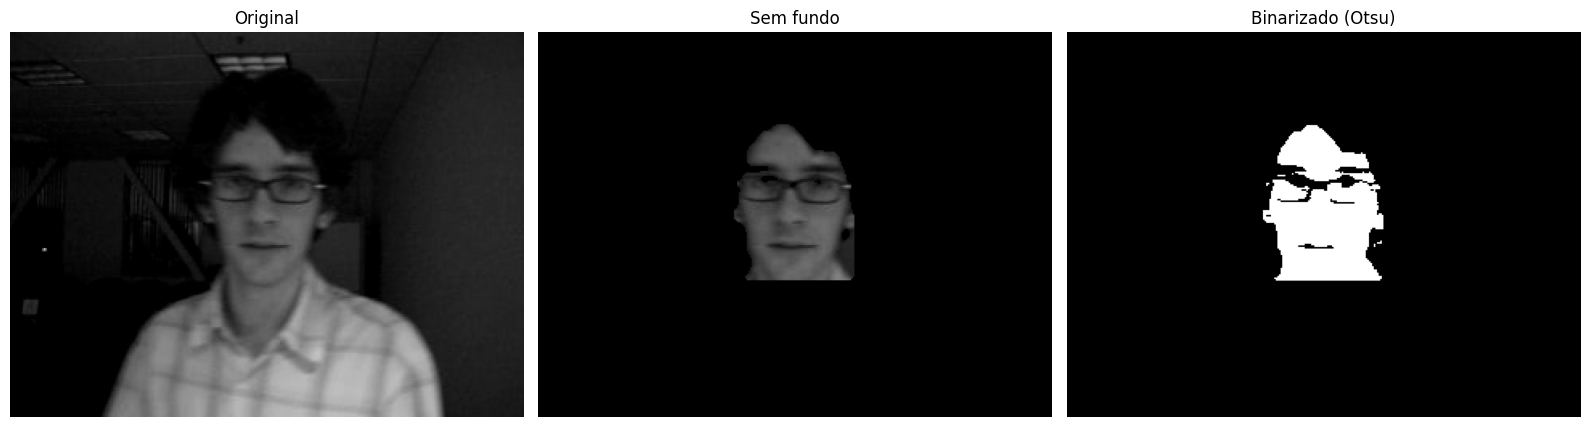

Resultado salvo em: preprocess_method_output/frame_binarizado.png


In [44]:
frame_binary = binarize_frame(frame_no_bg)
binary_vis   = (frame_binary * 255).astype(np.uint8)

# Salva resultado
binary_path = OUTPUT_DIR / 'frame_binarizado.png'
cv2.imwrite(str(binary_path), binary_vis)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(first_frame)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(frame_no_bg)
axes[1].set_title('Sem fundo')
axes[1].axis('off')
axes[2].imshow(binary_vis, cmap='gray')
axes[2].set_title('Binarizado (Otsu)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

print(f'Resultado salvo em: {binary_path}')

## 4. Regiões de busca

A função `generate_search_regions` (extraída de `T-wisard.py`) varre uma grade ao redor do centro do bounding box anterior, cobrindo um raio de `scale * max(w, h)` com passo `step`. Gera todas as posições candidatas mantendo o tamanho do bbox original.

In [45]:
def generate_search_regions(prev_bbox, frame_shape, scale, step):
    import numpy as np

    # Garante tipos corretos
    bx, by, bw, bh = map(int, prev_bbox)

    cx = bx + bw // 2
    cy = by + bh // 2

    radius = int(max(bw, bh) * scale)

    # Limites da imagem
    H, W = frame_shape[:2]

    for dx in range(-radius, radius, step):
        for dy in range(-radius, radius, step):

            nx = int(np.clip(cx + dx - bw // 2, 0, W - bw))
            ny = int(np.clip(cy + dy - bh // 2, 0, H - bh))

            yield (nx, ny, bw, bh)

In [50]:
import cv2
import matplotlib.pyplot as plt
import math

SCALE = 0.2
STEP  = 10

regions = list(generate_search_regions(first_gt, first_frame.shape, SCALE, STEP))
print(f'Regiões de busca geradas: {len(regions)}')

# bbox GT
x, y, w, h = map(int, first_gt)

# base
binary_rgb = cv2.cvtColor(binary_vis, cv2.COLOR_GRAY2RGB)

def draw_regions(base_img, regions_to_draw):
    img = base_img.copy()

    for i, (rx, ry, rw, rh) in enumerate(regions_to_draw):
        rx, ry, rw, rh = int(rx), int(ry), int(rw), int(rh)

        cv2.rectangle(img, (rx, ry), (rx + rw, ry + rh), (255, 0, 0), 1)
        cv2.putText(img, str(i+1), (rx, ry-2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)

    # GT
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

    return img


# --- gerar imagens cumulativas ---
images = []
titles = []

limit = min(len(regions), 10)

for i in range(limit):
    subset = regions[:i+1]
    images.append(draw_regions(binary_rgb, subset))
    titles.append(f"1 → {i+1}")

# todas
images.append(draw_regions(binary_rgb, regions))
titles.append(f"Todas ({len(regions)})")

# --- GRID ---
n = len(images)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = axes.flatten()

for i in range(len(axes)):
    if i < n:
        axes[i].imshow(images[i])
        axes[i].set_title(titles[i])
    axes[i].axis("off")

plt.tight_layout()

# --- salvar apenas o grid ---
grid_path = OUTPUT_DIR / "grid_regioes.png"
plt.savefig(grid_path, dpi=300)
plt.close()

print(f"Grid salvo em: {grid_path}")

Regiões de busca geradas: 16
Grid salvo em: preprocess_method_output/grid_regioes.png


### Resumo dos arquivos gerados

| Arquivo | Conteúdo |
|---|---|
| `frame_sem_fundo.png` | Frame após remoção de fundo (resultado intermediário) |
| `frame_binarizado.png` | Frame binarizado com Otsu |
| `sem_fundo_com_regioes.png` | Frame sem fundo com todas as regiões de busca |
| `binarizado_com_regioes.png` | Frame binarizado com todas as regiões de busca |

In [53]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(frame)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(frame_no_bg)
axes[1].set_title("Sem fundo")
axes[1].axis("off")

axes[2].imshow(grid_img)
axes[2].set_title("Regiões de busca")
axes[2].axis("off")

axes[3].axis("off")  # vazio

plt.tight_layout()
path1 = OUTPUT_DIR / "fig_pipeline.png"
plt.savefig(path1, dpi=300)
plt.close()

print(f"Figura 1 salva em: {path1}")

import matplotlib.pyplot as plt
import numpy as np

N_PATCHES = 16

patches = []
binary_patches = []

gray = cv2.cvtColor(frame_no_bg, cv2.COLOR_RGB2GRAY)

for (rx, ry, rw, rh) in regions:
    patch = gray[ry:ry+rh, rx:rx+rw]

    if patch.shape != (h, w):
        continue

    bin_patch = (patch >= np.mean(patch)).astype(np.uint8)

    patches.append(patch)
    binary_patches.append(bin_patch)

    if len(patches) == N_PATCHES:
        break

# =========================
# FIGURA 2
# =========================

fig = plt.figure(figsize=(12, 8))

# LEFT BLOCK (originais)
for i in range(N_PATCHES):
    ax = plt.subplot(4, 8, i + 1)
    ax.imshow(patches[i], cmap="gray")
    ax.axis("off")

# RIGHT BLOCK (binarizados)
for i in range(N_PATCHES):
    ax = plt.subplot(4, 8, i + 1 + 16)
    ax.imshow(binary_patches[i], cmap="gray")
    ax.axis("off")

# TÍTULOS DOS BLOCOS
fig.text(0.25, 0.95, "Regiões candidatas (originais)", ha="center", fontsize=14)
fig.text(0.75, 0.95, "Regiões candidatas (binarizadas)", ha="center", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.93])

path2 = OUTPUT_DIR / "fig_patches.png"
plt.savefig(path2, dpi=300)
plt.close()

print(f"Figura 2 salva em: {path2}")

Figura 1 salva em: preprocess_method2_output/fig_pipeline.png
Figura 2 salva em: preprocess_method2_output/fig_patches.png


In [54]:
import matplotlib.pyplot as plt
import numpy as np

N_PATCHES = 16

patches = []
binary_patches = []

gray = cv2.cvtColor(frame_no_bg, cv2.COLOR_RGB2GRAY)

# extrai patches
for (rx, ry, rw, rh) in regions:
    patch = gray[ry:ry+rh, rx:rx+rw]

    if patch.shape != (h, w):
        continue

    bin_patch = (patch >= np.mean(patch)).astype(np.uint8)

    patches.append(patch)
    binary_patches.append(bin_patch)

    if len(patches) == N_PATCHES:
        break

# =========================
# FIGURA
# =========================

fig, axes = plt.subplots(4, 8, figsize=(14, 7))

idx = 0
for row in range(4):
    for col in range(4):
        # esquerda (originais)
        axes[row, col].imshow(patches[idx], cmap="gray")
        axes[row, col].set_title(f"P{idx+1}", fontsize=8)
        axes[row, col].axis("off")

        # direita (binarizados)
        axes[row, col + 4].imshow(binary_patches[idx], cmap="gray")
        axes[row, col + 4].set_title(f"R{idx+1}", fontsize=8)
        axes[row, col + 4].axis("off")

        idx += 1

# títulos dos blocos
fig.text(0.25, 0.95, "Regiões candidatas (originais)", ha="center", fontsize=14)
fig.text(0.75, 0.95, "Regiões candidatas (binarizadas)", ha="center", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.93])

path2 = OUTPUT_DIR / "fig_patches_alinhado.png"
plt.savefig(path2, dpi=300)
plt.close()

print(f"✅ Figura salva em: {path2}")

✅ Figura salva em: preprocess_method2_output/fig_patches_alinhado.png
